### Load Dependencies

In [1]:
import torch
import torch.optim as optim
import torch.distributed as dist
from torch.utils.data import DataLoader
import numpy as np
from torch.utils.data import SubsetRandomSampler

from src.dataset import DSMShadeDataset
from src.model import ShadyModel

### Define Parameters

In [2]:
# Directory containing training data
TEST_TILE_PATH = "/Users/luc/Geomatics/Thesis/Data/input/271110_Ams/test_tiles/dsms/combined/"
TEST_SHADE_PATH = "/Users/luc/Geomatics/Thesis/Data/output/tree_shade/"
CSV_PATH = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/resources/dataset.csv"

# Set Acceleration Device
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
else "cpu")
print(device)
# Hyperparameters
tile_size = 512
epochs = 10
LAMBDA = 100
optimizer_learning_rate = 0.0002
# Todo experiment with not messing with this value? (defined in DCGAN paper apparently)
optimizer_momentum = 0.5
# # Todo, how to find how many GPUS are available?
ngpu = 1
if device == torch.device("cpu"):
    ngpu = 0

mps


In [3]:
# Instantiate the custom dataset
dataset = DSMShadeDataset(CSV_PATH, TEST_TILE_PATH, TEST_SHADE_PATH, tile_size=tile_size)

# Define train and test dataloaders
batch_size = 16
validation_split = .2
shuffle_dataset = True
random_seed = 42

# Creating data indices for training and validation splits:
dataset_size = len(dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))
if shuffle_dataset:
    np.random.seed(random_seed)
    np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

# Create data samplers and loaders:
train_sampler = SubsetRandomSampler(train_indices)
valid_sampler = SubsetRandomSampler(val_indices)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
validation_loader = DataLoader(dataset, batch_size=batch_size, sampler=valid_sampler)

print(len(train_loader), len(validation_loader))

1235 309


In [4]:
model = ShadyModel(ngpu, device, tile_size)
model.setup_models()
# disc_loss = nn.BCELoss  # bce loss
# disc_optimizer = optim.Adam(model.parameters(), lr=optimizer_learning_rate, betas=(optimizer_momentum, 0.999))
gen_optimizer = optim.Adam(params=model.generator.parameters(), lr=optimizer_learning_rate, betas=(optimizer_momentum, 0.999))

### Training Loop

Epoch 0 | Loss 0.2625


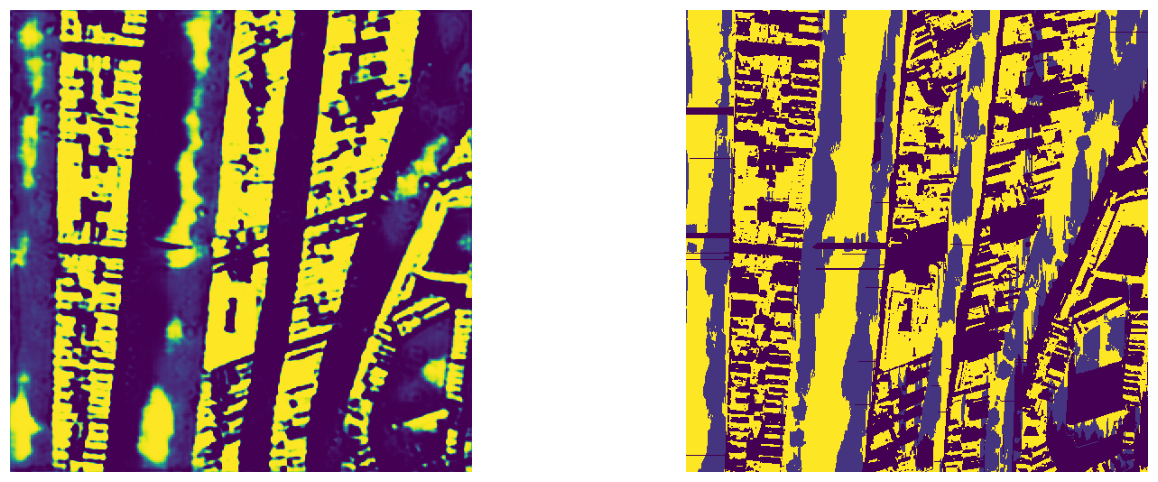

Epoch 100 | Loss 0.2307


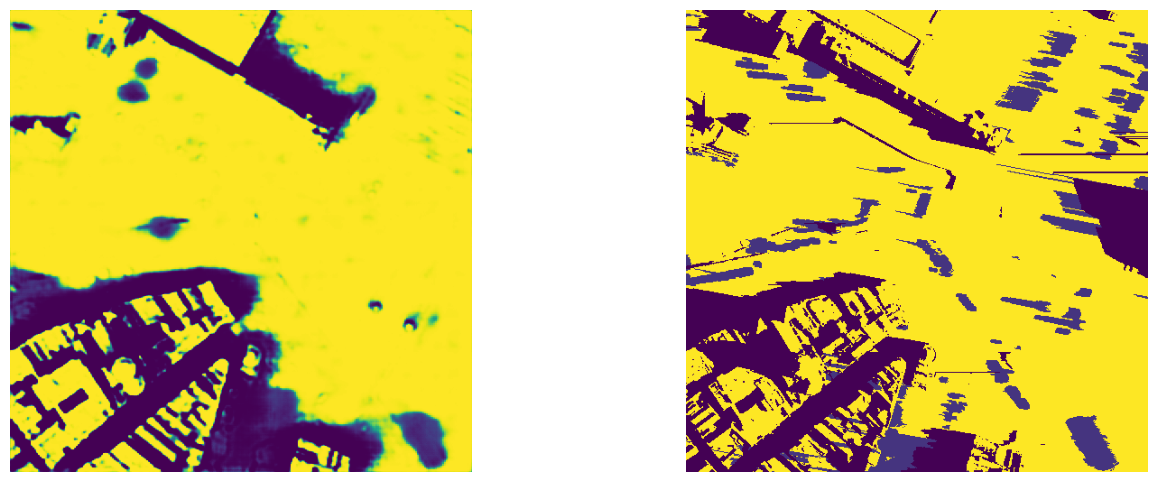

Epoch 200 | Loss 0.2490


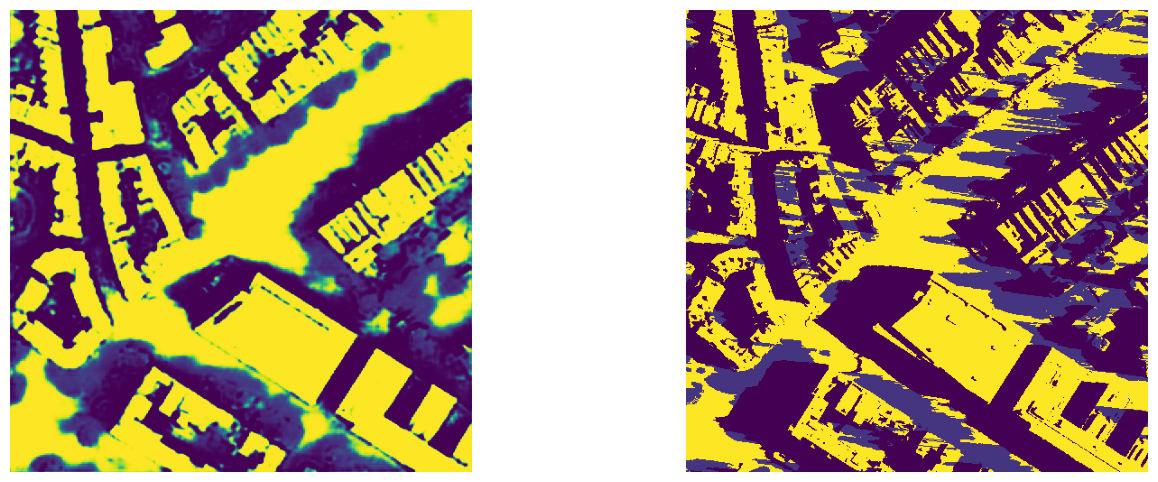

Epoch 300 | Loss 0.2445


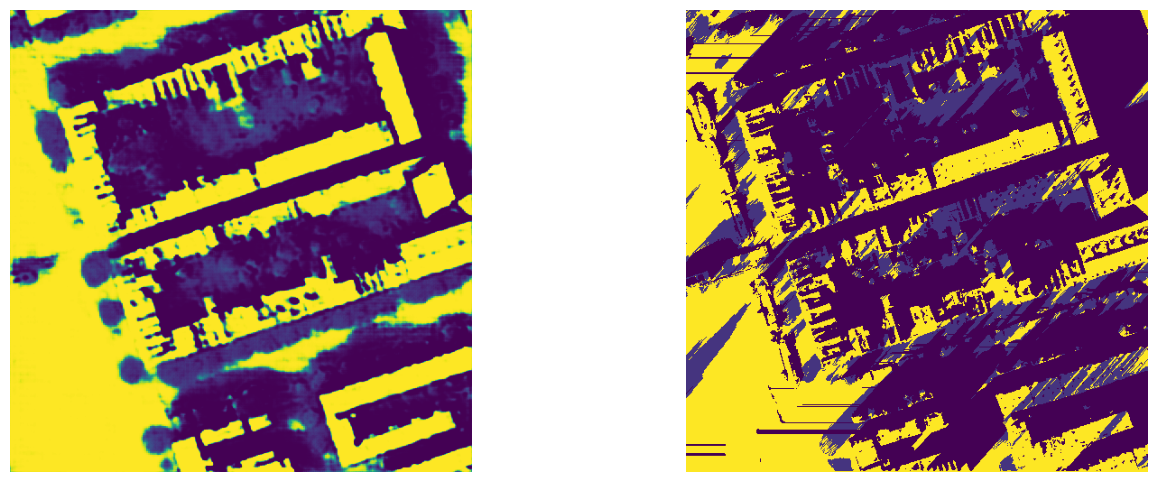

Epoch 400 | Loss 0.2042


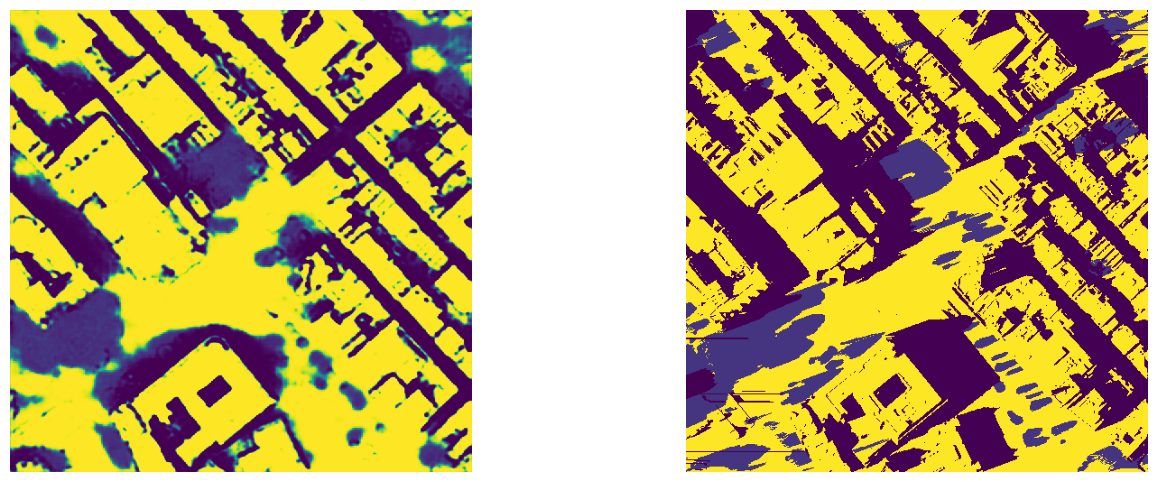

Epoch 500 | Loss 0.2357


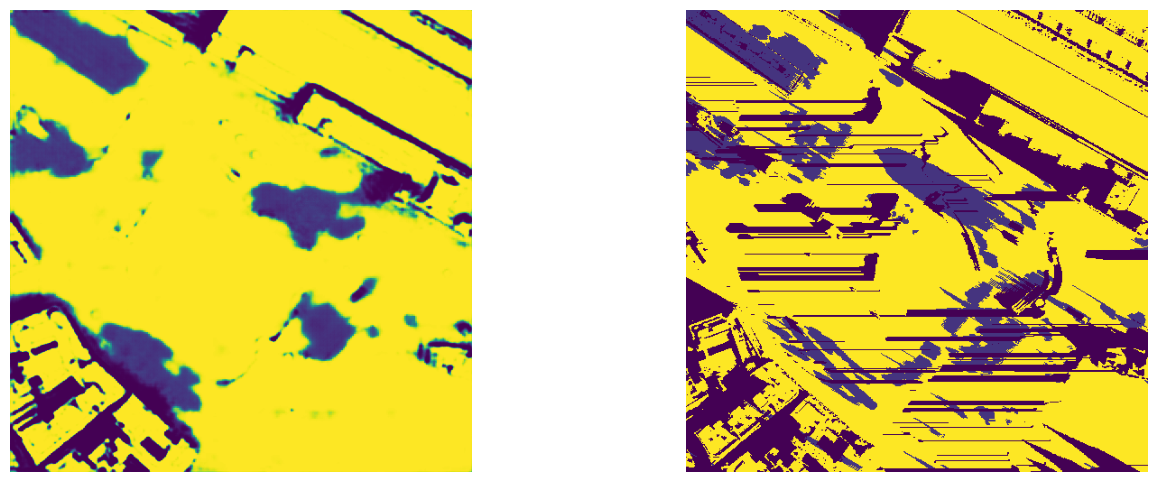

Epoch 600 | Loss 0.2372


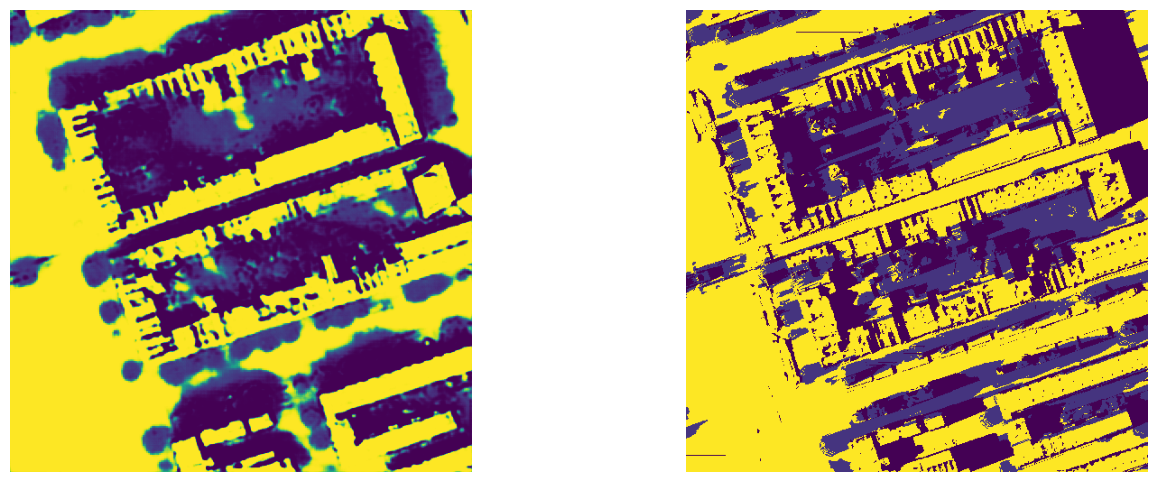

Epoch 700 | Loss 0.2126


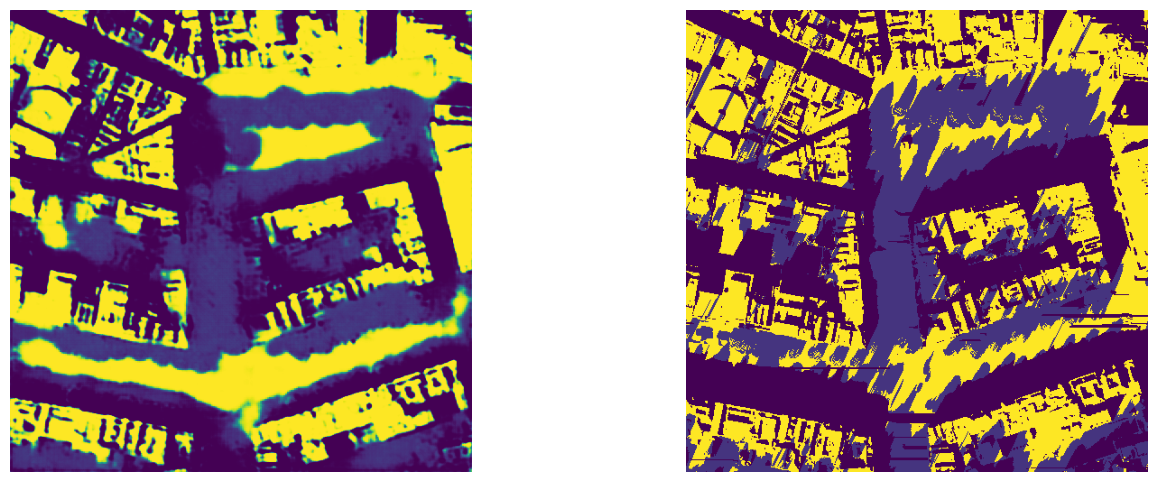

Epoch 800 | Loss 0.2182


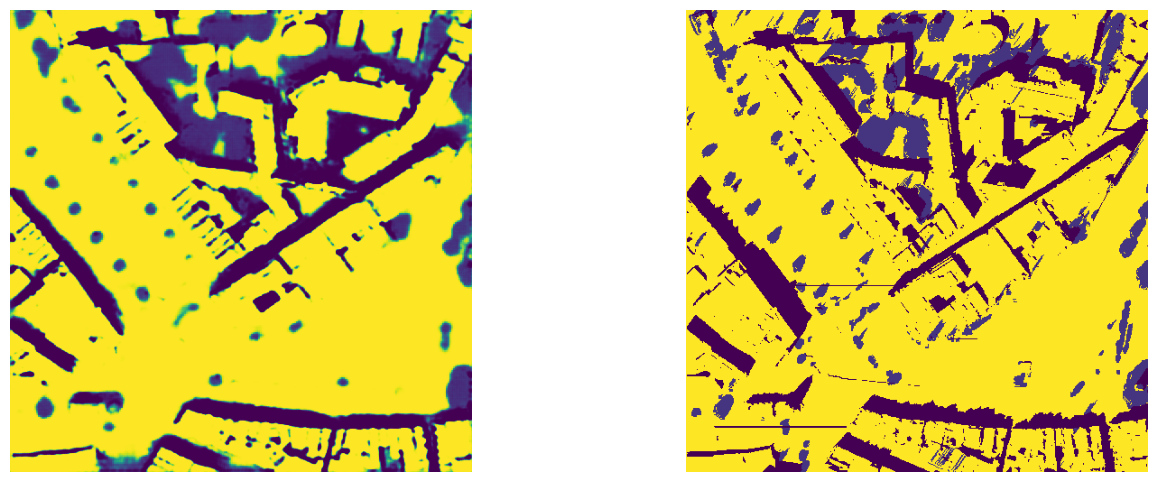

Epoch 900 | Loss 0.1966


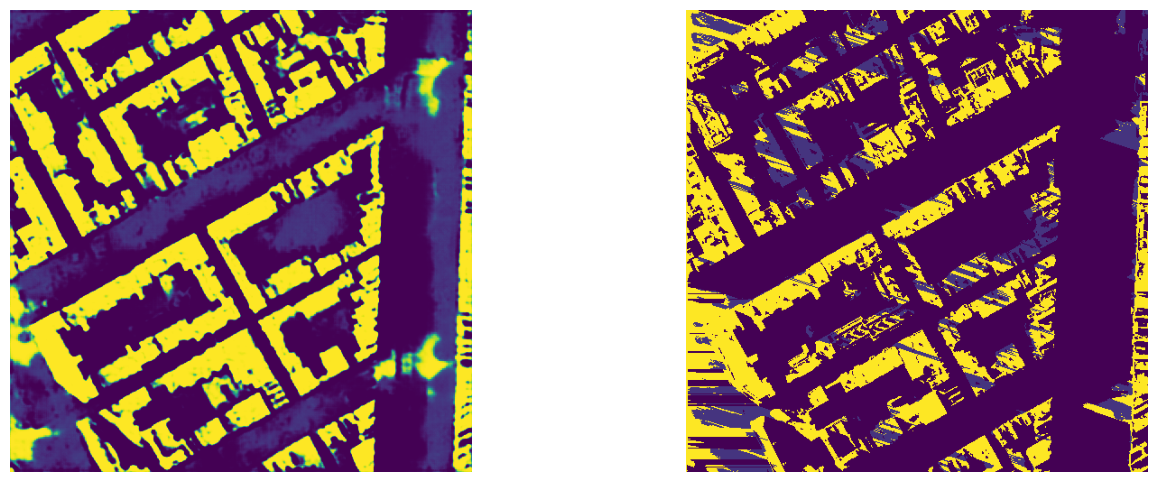

Epoch 1000 | Loss 0.2541


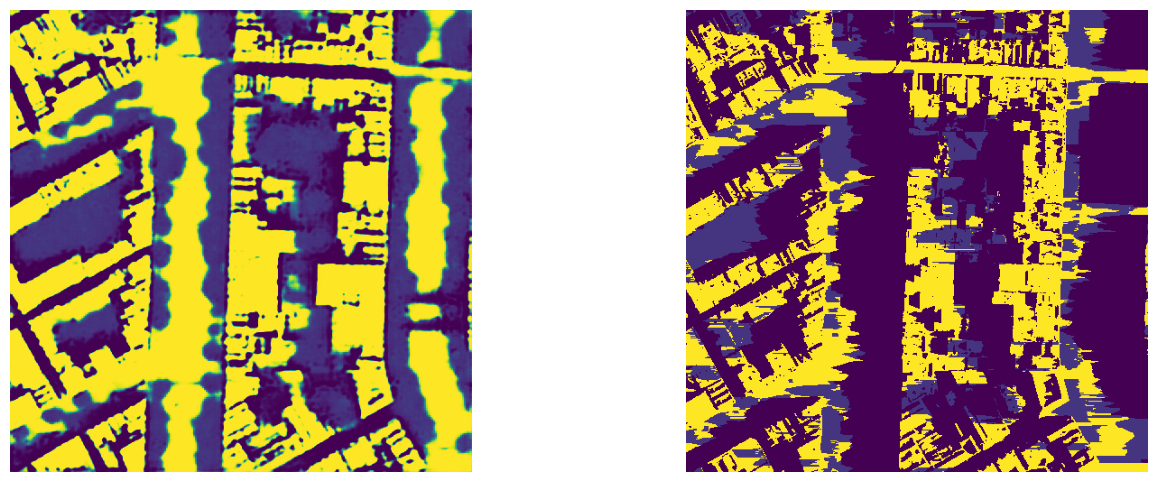

Epoch 1100 | Loss 0.2060


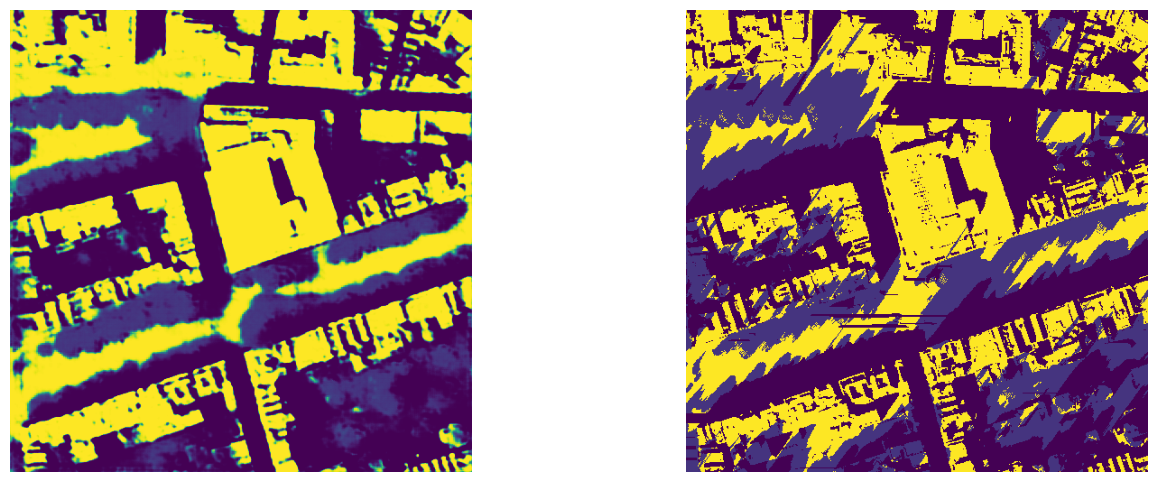

Epoch 1200 | Loss 0.2101


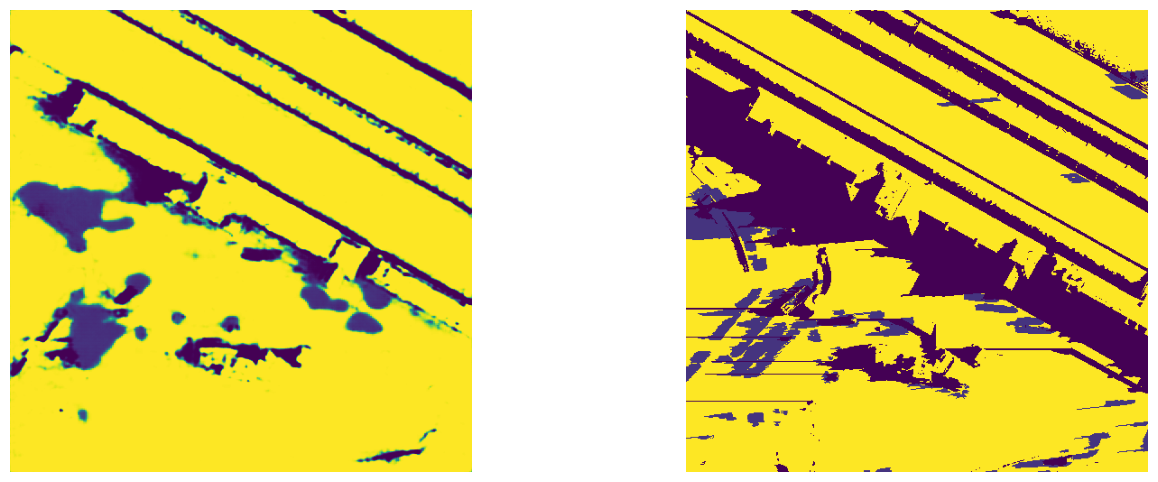

In [11]:
from matplotlib import pyplot as plt

def display_res(result, target):
    result_cpu = result.cpu().detach()
    target_cpu = target.cpu().detach()

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    result = result_cpu[0]
    plt.imshow(result.squeeze().numpy())
    plt.axis('off')

    plt.subplot(1, 2, 2)
    result = target_cpu[0]
    plt.imshow(result.squeeze().numpy())
    plt.axis('off')

    plt.show()

# Todo include epochs
for epoch in range(epochs):
    for i, data in enumerate(train_loader, 0):
        source = data["source"]
        target = data["target"]
        source, target = source.to(device), target.to(device)
        ### FORWARD PASS ###
        y_hat = model.generator(source)

        ### LOSS CALCULATION ###
        loss = model.discriminator(y_hat, target)

        ### BACKPROPAGATION ###
        gen_optimizer.zero_grad()
        loss.backward()
        gen_optimizer.step()

        # Todo: How does discriminator optimization look, same time?

        # TODO: TESTING IF PIPELINE WORKS AT ALL
        if i % 600 == 0:
            print(f"Epoch {i} | Loss {loss.item():.4f}")
            display_res(y_hat, target)